<a href="https://colab.research.google.com/github/shareotherban/CTC/blob/main/CTC_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
print("Hello Speech to Text")

Hello Speech to Text


In [67]:
#!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

In [ ]:
from datasets import load_dataset

ds = load_dataset("krandiash/sc09")
ds.save_to_disk("/content/sc09")

Repo card metadata block was not found. Setting CardData to empty.


Saving the dataset (0/4 shards):   0%|          | 0/39405 [00:00<?, ? examples/s]

In [41]:
import os

recordings_dir = "free-spoken-digit-dataset/recordings"
files = sorted(os.listdir(recordings_dir))

print(f"Total files: {len(files)}")

Total files: 3000


In [42]:
import torchaudio
import matplotlib.pyplot as plt

filepath = os.path.join(recordings_dir, files[1])
waveform, sample_rate = torchaudio.load(filepath)

print("File:", filepath)
print("Waveform tensor shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Min amplitude:", waveform.min().item())
print("Max amplitude:", waveform.max().item())

duration_seconds = waveform.shape[1] / sample_rate
print(f"Duration: {duration_seconds:.3f} seconds")

File: free-spoken-digit-dataset/recordings/0_george_1.wav
Waveform tensor shape: torch.Size([1, 4727])
Sample rate: 8000
Min amplitude: -0.262664794921875
Max amplitude: 0.232086181640625
Duration: 0.591 seconds


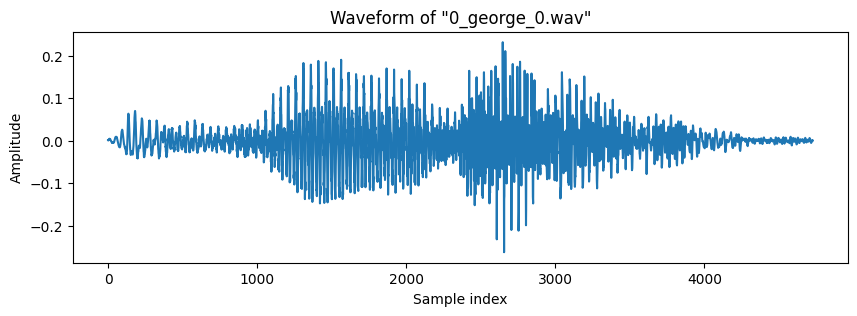

In [43]:
plt.figure(figsize=(10, 3))
plt.plot(waveform[0].numpy())
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title(f'Waveform of "{files[0]}"')
plt.show()

In [44]:
import torch

n_fft = int(0.025 * sample_rate)      # 25ms window
hop_length = int(0.010 * sample_rate) # 10ms hop between windows
n_mels = 40

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels
)

mel_spec = mel_transform(waveform)          # shape: [1, n_mels, n_frames]
log_mel_spec = torch.log(mel_spec + 1e-9)   # avoid log(0)

print("n_fft (samples per window):", n_fft)
print("hop_length (samples between windows):", hop_length)
print("Mel spectrogram shape:", mel_spec.shape)

n_fft (samples per window): 200
hop_length (samples between windows): 80
Mel spectrogram shape: torch.Size([1, 40, 60])


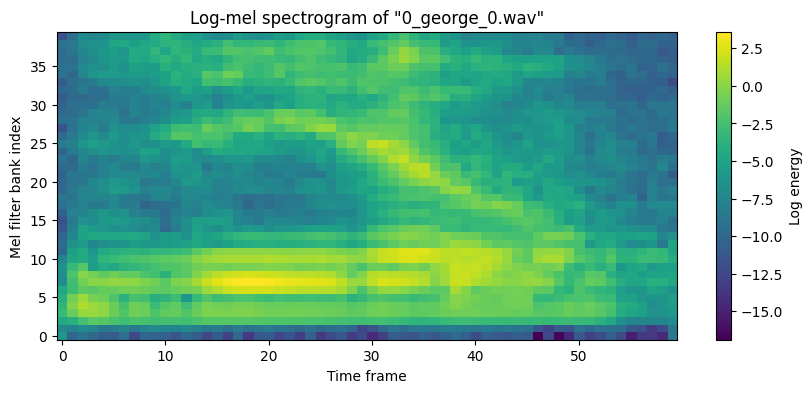

In [45]:
plt.figure(figsize=(10, 4))
plt.imshow(log_mel_spec[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
plt.xlabel("Time frame")
plt.ylabel("Mel filter bank index")
plt.title(f'Log-mel spectrogram of "{files[0]}"')
plt.colorbar(label="Log energy")
plt.show()

In [46]:
import torch
from torch.utils.data import Dataset

class FSDDDataset(Dataset):
    def __init__(self, recordings_dir, file_list):
        self.recordings_dir = recordings_dir
        self.file_list = file_list
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=8000, n_fft=200, hop_length=80, n_mels=40
        )

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        filepath = os.path.join(self.recordings_dir, filename)

        label = int(filename.split("_")[0])

        waveform, sr = torchaudio.load(filepath)
        mel_spec = self.mel_transform(waveform)
        log_mel_spec = torch.log(mel_spec + 1e-9)
        log_mel_spec = log_mel_spec.squeeze(0)
        return log_mel_spec, label

In [47]:
dataset = FSDDDataset(recordings_dir, files)
spec, label = dataset[0]
print("Spectrogram shape:", spec.shape)
print("Label:", label)

Spectrogram shape: torch.Size([40, 30])
Label: 0


In [48]:
from torch.utils.data import DataLoader

try:
    loader = DataLoader(dataset, batch_size=4)
    batch = next(iter(loader))
except RuntimeError as e:
    print("Error:", e)

Error: stack expects each tensor to be equal size, but got [40, 30] at entry 0 and [40, 60] at entry 1


In [49]:
def collate_fn(batch):
    specs, labels = zip(*batch)

    lengths = torch.tensor([s.shape[1] for s in specs])
    max_len = lengths.max().item()

    padded_specs = []
    for s in specs:
        pad_amount = max_len - s.shape[1]
        padded = torch.nn.functional.pad(s, (0, pad_amount))
        padded_specs.append(padded)

    specs_batch = torch.stack(padded_specs)
    labels_batch = torch.tensor(labels)

    return specs_batch, labels_batch, lengths

In [50]:
loader = DataLoader(dataset, batch_size=4, collate_fn=collate_fn)
specs_batch, labels_batch, lengths = next(iter(loader))

print("Batch spectrogram shape:", specs_batch.shape)
print("Batch labels:", labels_batch)
print("Batch lengths:", lengths)

Batch spectrogram shape: torch.Size([4, 40, 75])
Batch labels: tensor([0, 0, 0, 0])
Batch lengths: tensor([30, 60, 75, 46])


In [51]:
import torch.nn as nn

class CTCSpeechModel(nn.Module):
    def __init__(self, n_mels=40, hidden_size=128, num_classes=11):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=n_mels,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        rnn_out, _ = self.rnn(x)
        logits = self.classifier(rnn_out)
        return logits

In [52]:
model = CTCSpeechModel()
logits = model(specs_batch)
print("Logits shape:", logits.shape)

Logits shape: torch.Size([4, 75, 11])


In [53]:
criterion = nn.CTCLoss(blank=10, zero_infinity=True)

log_probs = torch.nn.functional.log_softmax(logits, dim=2)  # (batch, frames, classes)
log_probs = log_probs.permute(1, 0, 2)                       # -> (frames, batch, classes)

target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long)  # each clip = one digit
targets = labels_batch                                                 # values already 0-9

loss = criterion(log_probs, targets, lengths, target_lengths)
print("Loss:", loss.item())

Loss: 128.8965301513672


In [54]:
import random

random.seed(42)  # makes the shuffle reproducible - same split every time we rerun this

shuffled_files = files.copy()
random.shuffle(shuffled_files)

split_idx = int(0.8 * len(shuffled_files))  # 80% for training, 20% held out for testing
train_files = shuffled_files[:split_idx]
test_files = shuffled_files[split_idx:]

print(f"Total files: {len(shuffled_files)}")
print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")

Total files: 3000
Train files: 2400
Test files: 600


In [55]:
train_dataset = FSDDDataset(recordings_dir, train_files)
test_dataset = FSDDDataset(recordings_dir, test_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,       # reshuffle order every epoch during training
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,       # order doesn't matter for evaluation
    collate_fn=collate_fn
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 75
Number of test batches: 19


In [56]:
model = CTCSpeechModel()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CTCLoss(blank=10, zero_infinity=True)

num_epochs = 20

for epoch in range(num_epochs):

    model.train()
    total_train_loss = 0.0

    for specs_batch, labels_batch, lengths in train_loader:
        optimizer.zero_grad()

        logits = model(specs_batch)
        log_probs = torch.nn.functional.log_softmax(logits, dim=2)
        log_probs = log_probs.permute(1, 0, 2)
        target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long)
        loss = criterion(log_probs, labels_batch, lengths, target_lengths)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for specs_batch, labels_batch, lengths in test_loader:
            logits = model(specs_batch)
            log_probs = torch.nn.functional.log_softmax(logits, dim=2)
            log_probs = log_probs.permute(1, 0, 2)

            target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long)
            loss = criterion(log_probs, labels_batch, lengths, target_lengths)

            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {avg_train_loss:.4f} | Test loss: {avg_test_loss:.4f}")

Epoch 1/20 | Train loss: 5.4396 | Test loss: 3.2241
Epoch 2/20 | Train loss: 3.0616 | Test loss: 2.8090
Epoch 3/20 | Train loss: 2.3981 | Test loss: 1.9879
Epoch 4/20 | Train loss: 1.4165 | Test loss: 0.8686
Epoch 5/20 | Train loss: 0.4928 | Test loss: 0.3769
Epoch 6/20 | Train loss: 0.2564 | Test loss: 0.1881
Epoch 7/20 | Train loss: 0.1581 | Test loss: 0.1422
Epoch 8/20 | Train loss: 0.1146 | Test loss: 0.0911
Epoch 9/20 | Train loss: 0.0892 | Test loss: 0.1371
Epoch 10/20 | Train loss: 0.0829 | Test loss: 0.0689
Epoch 11/20 | Train loss: 0.0728 | Test loss: 0.1349
Epoch 12/20 | Train loss: 0.0704 | Test loss: 0.0713
Epoch 13/20 | Train loss: 0.0647 | Test loss: 0.1026
Epoch 14/20 | Train loss: 0.0308 | Test loss: 0.0416
Epoch 15/20 | Train loss: 0.0288 | Test loss: 0.0524
Epoch 16/20 | Train loss: 0.0518 | Test loss: 0.0499
Epoch 17/20 | Train loss: 0.0314 | Test loss: 0.0404
Epoch 18/20 | Train loss: 0.0230 | Test loss: 0.0888
Epoch 19/20 | Train loss: 0.0210 | Test loss: 0.0440
Ep

In [63]:
# # #greedy_decode
# def greedy_decode(logits, lengths):
#     pred_indices = torch.argmax(logits, dim=2)

#     decoded_batch = []
#     for i, sequence in enumerate(pred_indices):
#         real_length = lengths[i].item()
#         sequence = sequence[:real_length].tolist()

#         collapsed = []
#         previous = None
#         for idx in sequence:
#             if idx != previous:
#                 collapsed.append(idx)
#             previous = idx
#         decoded = [c for c in collapsed if c != 10]
#         decoded_batch.append(decoded)

#     return decoded_batch

In [64]:
# model.eval()
# correct = 0
# total = 0

# with torch.no_grad():
#     for specs_batch, labels_batch, lengths in test_loader:
#         logits = model(specs_batch)
#         predictions = greedy_decode(logits, lengths)

#         for pred, true_label in zip(predictions, labels_batch.tolist()):
#             if pred == [true_label]:
#                 correct += 1
#             total += 1

# print(f"Test accuracy: {correct}/{total} = {correct/total:.2%}")

In [65]:
import math
from collections import defaultdict

NEG_INF = float("-inf")

def logaddexp(*args):
    m = max(args)
    if m == NEG_INF:
        return NEG_INF
    return m + math.log(sum(math.exp(a - m) for a in args))


def beam_search_single(log_probs, beam_width=10, blank=10):
    lp = log_probs.tolist()
    beams = {(): (0.0, NEG_INF)}

    for t in range(len(lp)):
        new_beams = defaultdict(lambda: (NEG_INF, NEG_INF))
        for prefix, (p_b, p_nb) in beams.items():
            for c, p in enumerate(lp[t]):
                if c == blank:
                    o_b, o_nb = new_beams[prefix]
                    new_beams[prefix] = (logaddexp(o_b, p_b + p, p_nb + p), o_nb)
                else:
                    last = prefix[-1] if prefix else None
                    if c == last:
                        #("aa" -> "a")...
                        o_b, o_nb = new_beams[prefix]
                        new_beams[prefix] = (o_b, logaddexp(o_nb, p_nb + p))
                        # ("a_a" -> "aa")
                        ext = prefix + (c,)
                        n_b, n_nb = new_beams[ext]
                        new_beams[ext] = (n_b, logaddexp(n_nb, p_b + p))
                    else:
                        ext = prefix + (c,)
                        n_b, n_nb = new_beams[ext]
                        new_beams[ext] = (n_b, logaddexp(n_nb, p_b + p, p_nb + p))

        beams = dict(sorted(new_beams.items(),
                            key=lambda kv: logaddexp(*kv[1]),
                            reverse=True)[:beam_width])

    best_prefix, (p_b, p_nb) = max(beams.items(), key=lambda kv: logaddexp(*kv[1]))
    return list(best_prefix), logaddexp(p_b, p_nb)


def beam_search_decode(logits, lengths, beam_width=10, blank=10):
    log_probs = torch.nn.functional.log_softmax(logits, dim=2)

    decoded_batch = []
    for i in range(log_probs.shape[0]):
        real_length = lengths[i].item()
        sequence, score = beam_search_single(
            log_probs[i, :real_length], beam_width=beam_width, blank=blank
        )
        decoded_batch.append(sequence)

    return decoded_batch

In [66]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for specs_batch, labels_batch, lengths in test_loader:
        logits = model(specs_batch)
        predictions = beam_search_decode(logits, lengths, beam_width=10)

        for pred, true_label in zip(predictions, labels_batch.tolist()):
            if pred == [true_label]:
                correct += 1
            total += 1

print(f"Beam search test accuracy: {correct}/{total} = {correct/total:.2%}")

Beam search test accuracy: 593/600 = 98.83%
